## Set up

Author: Almudena Ramirez Haro

In [1]:
import pandas as pd
import glob
import os
import scipy
import matplotlib.pyplot as plt

import seaborn as sns
import numpy as np
import re

import scipy.stats as stats


In [2]:
path = os.path.expanduser('~/projects/phd/hybrids/exp3')
datapath = glob.glob(path + '/analysis/raw/*.csv')

print(len(datapath))

255


In [3]:
complete_data = []
for f in datapath:
    df = pd.read_csv(f)
    if len(df)== 1452:
        complete_data.append(df)

print(len(complete_data))


134


In [4]:
alldata = pd.DataFrame()

s=0
c =[]
for f in datapath:
    data =pd.read_csv(f)
    if len(data) == 1452:
        s+=1
        print(s)
        clean_data = data.dropna(subset=['stim'])
        clean_data = clean_data[clean_data['test_part']=='response']
        clean_data['subject'] = s
        clean_data['inanimate'] = [int('inanimate' in x) for x in clean_data['stim']] #0 animate, 1 inanimate
        clean_data['control'] = [int('stim1' in x) for x in clean_data['stim']] #0 hybrids, 1 controls
        clean_data['blurred'] = [int('blurred' in x) for x in clean_data['stim']] # 0 normal, 1 blurred


        for idx, row in clean_data.iterrows():
            inanimate = row['inanimate']
            control = row['control']
            task = row['task']
            lsf = row['blurred']

            if control:
                
                if '[z] inanimate' in task and inanimate:
                    c.append('z')
                elif '[z] inanimate' in task and not inanimate:
                    c.append('m')
                elif '[z] animate' in task and inanimate:
                    c.append('m')
                elif '[z] animate' in task and not inanimate:
                    c.append('z')
                
            else:
                print(row['stim'])
                if '[z] inanimate' in task and inanimate and not lsf: # clear inanimate
                    c.append('z')
                elif '[z] inanimate' in task and not inanimate and not lsf: # clear animate
                    c.append('m')
                elif '[z] inanimate' in task and inanimate and lsf: # blurry inanimate (lsf animate)
                    c.append('m')
                elif '[z] inanimate' in task and not inanimate and lsf: # blurry animate (lsf inanimate)
                    c.append('z')
                
                elif '[z] animate' in task and not inanimate and not lsf: #clear animate
                    c.append('z') 
                elif '[z] animate' in task and not inanimate and lsf: #lsf inanimate
                    c.append('m')
                elif '[z] animate' in task and inanimate and lsf: #lsf animate
                    c.append('z') 
                elif '[z] animate' in task and inanimate and not lsf: #clear inanimate
                    c.append('m') 


        clean_data['zrt'] = scipy.stats.zscore(clean_data['rt'])
        alldata = pd.concat((alldata,clean_data))

alldata['cresp'] = c
alldata['correct'] = [int(x==y) for x,y in zip(alldata['response'],alldata['cresp'])]


with open('all_responses.csv','w') as out:
    alldata.to_csv(out,index_label='index')

1
stim/stim010-animate-parrots-fruits_mirrored_blurred.png
stim/stim014-animate-birds-bottles.png
stim/stim001-inanimate-armchairs-butterflies.png
stim/stim010-animate-parrots-fruits_blurred.png
stim/stim005-inanimate-fruits-buttleflies_mirrored.png
stim/stim004-inanimate-fruits-lizards.png
stim/stim003-inanimate-fruits-beetles_mirrored_blurred.png
stim/stim013-animate-chickens-armchairs_mirrored.png
stim/stim011-animate-parrots-fruits_mirrored_blurred.png
stim/stim001-inanimate-armchairs-butterflies_mirrored.png
stim/stim009-inanimate-handbags-lizards.png
stim/stim000-inanimate-flowers-dogs_mirrored.png
stim/stim000-inanimate-flowers-dogs_mirrored_blurred.png
stim/stim004-inanimate-fruits-lizards_blurred.png
stim/stim016-animate-fish-pillows_mirrored.png
stim/stim002-inanimate-armchairs-chickens_mirrored_blurred.png
stim/stim019-animate-peacocks-flowers_mirrored.png
stim/stim006-inanimate-fruits-parrots_mirrored_blurred.png
stim/stim015-animate-birds-fruits_mirrored.png
stim/stim008-i

## Demographic data

In [6]:
responses_path = f'{path}//analysis/code/all_responses.csv'

Responses = pd.read_csv(responses_path)

In [8]:
import json

demographic = []
for f in datapath:
    data = pd.read_csv(f)
    if len(data)==1452: #only keep full datasets
        demographic.append(data[data['trial_type']=='survey-html-form'])
demographic = pd.concat(demographic, ignore_index=True)

ages = []
gender = []
handendess = []
for dem in demographic['response']:
    dem_dict = json.loads(dem)
    if 'age' in dem_dict:
        try:
            ages.append(float(dem_dict['age']))
        except ValueError:
            pass
    if 'gender' in dem_dict:
        gender.append(dem_dict['gender'])
    if 'handedness' in dem_dict:
        handendess.append(dem_dict['handedness'])

print("Ages", "min:", np.min(ages), "max:", np.max(ages), "means ages:", np.mean(ages), "median ages:", np.median(ages), "std ages:", np.std(ages))
print("Genders:", pd.Series(gender).unique(), pd.Series(gender).value_counts())
print("Handendess", pd.Series(handendess).unique(), pd.Series(handendess).value_counts())

Ages min: 18.0 max: 55.0 means ages: 21.328358208955223 median ages: 19.0 std ages: 5.088435996120195
Genders: ['male' 'female'] female    110
male       24
Name: count, dtype: int64
Handendess ['right' 'left'] right    118
left      16
Name: count, dtype: int64


## Accuracy

### Accuracy accross different conditions

In [5]:
subjectnr = np.unique(alldata['subject'])

alldata['inanimate'] = alldata['inanimate'].astype(int)
alldata['control'] = alldata['control'].astype(int)
alldata['blurred'] = alldata['blurred'].astype(int)

# per-subject mean by animacy (inanimate: 0 -> animate, 1 -> inanimate)
by_animacy = alldata.groupby(['subject', 'inanimate'])['correct'] \
                   .mean().unstack(fill_value=np.nan) \
                   .rename(columns={0: 'animate', 1: 'inanimate'})

# per-subject mean by stimulus type (control: 0 -> hybrid, 1 -> control)
by_type = alldata.groupby(['subject', 'control'])['correct'] \
                 .mean().unstack(fill_value=np.nan) \
                 .rename(columns={0: 'hybrid', 1: 'control'})

# per-subject mean by spatial frequency (blurred: 0 -> hsf/clear, 1 -> lsf/blurry)
by_blur = alldata.groupby(['subject', 'blurred'])['correct'] \
                 .mean().unstack(fill_value=np.nan) \
                 .rename(columns={0: 'hsf', 1: 'lsf'})

# per-subject means for control x blur combinations
comb = alldata.groupby(['subject', 'control', 'blurred'])['correct'] \
              .mean().unstack(level=[1, 2])



# debug: show current multiindex columns
print("before:", comb.columns.tolist())

# mapping tuples -> new names
mapping = {
    (1, 0): 'control_hsf',
    (1, 1): 'control_lsf',
    (0, 0): 'hybrid_hsf',
    (0, 1): 'hybrid_lsf'
}

# assign new single-level column names
comb.columns = [mapping.get(tuple(col), tuple(col)) for col in comb.columns]

# debug: check result
print("after:", comb.columns.tolist())

# combine into one per-subject DataFrame
Avg_acc = pd.concat([by_animacy, by_type, by_blur, comb], axis=1)

# reorder columns if present
cols = ['animate','inanimate','hybrid','control','hsf','lsf',
        'control_lsf','control_hsf','hybrid_hsf','hybrid_lsf']
Avg_acc = Avg_acc.reindex(columns=[c for c in cols if c in Avg_acc.columns])

Avg_acc.to_csv('average_accuracy.csv', index_label='subject')

before: [(0, 0), (0, 1), (1, 0), (1, 1)]
after: ['hybrid_hsf', 'hybrid_lsf', 'control_hsf', 'control_lsf']


#### Cleaning data using accuracies of control (>.6)

In [6]:
# remove subjects whose control accuracy < 0.6 (do not mutate while iterating)
cond = (Avg_acc['control_hsf'] < 0.6) | (Avg_acc['control_lsf'] < 0.6)
outlier_idx = Avg_acc.index[cond]

outliers = []
# log the removed subjects using the original Avg_acc values
for subj in outlier_idx:
    outliers.append(int(subj))
    print(f'Removing subject {subj} with control accuracies {Avg_acc.loc[subj, "control_hsf"]} (clear) and {Avg_acc.loc[subj, "control_lsf"]} (blurry)')

# drop all outliers at once
Avg_acc = Avg_acc.drop(index=outlier_idx)

print(outliers)

Removing subject 3 with control accuracies 0.55 (clear) and 0.575 (blurry)
Removing subject 5 with control accuracies 0.4875 (clear) and 0.5375 (blurry)
Removing subject 6 with control accuracies 0.25 (clear) and 0.275 (blurry)
Removing subject 10 with control accuracies 0.4625 (clear) and 0.5125 (blurry)
Removing subject 11 with control accuracies 0.5 (clear) and 0.3875 (blurry)
Removing subject 12 with control accuracies 0.575 (clear) and 0.5125 (blurry)
Removing subject 16 with control accuracies 0.525 (clear) and 0.45 (blurry)
Removing subject 18 with control accuracies 0.4625 (clear) and 0.4375 (blurry)
Removing subject 21 with control accuracies 0.525 (clear) and 0.5625 (blurry)
Removing subject 22 with control accuracies 0.475 (clear) and 0.45 (blurry)
Removing subject 27 with control accuracies 0.4625 (clear) and 0.425 (blurry)
Removing subject 29 with control accuracies 0.6 (clear) and 0.4 (blurry)
Removing subject 38 with control accuracies 0.3875 (clear) and 0.525 (blurry)
R

In [7]:
print(Avg_acc.shape) #ppts x conditions

(93, 10)


#### Plots

In [13]:
bf_results = pd.read_csv('bayes_factors_results.csv')

bf_results

,acc_animacy,acc_stim_type,acc_sf,acc_control_sf,acc_hybrid_sf,rt_animacy,rt_stim_type,rt_sf,rt_control_sf,rt_hybrids_sf
0,2.372662,3505.057695,126.865599,3.473326,79990.466151,0.443505,0.43711,0.656397,0.457606,1.264025


C:\Users\90957667\AppData\Local\Temp\ipykernel_3220\494657444.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Animate HSF', 'Inanimate HSF'], fontsize=tick_fontsize)
C:\Users\90957667\AppData\Local\Temp\ipykernel_3220\494657444.py:48: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Hybrid images', 'Control images'], fontsize=tick_fontsize)
C:\Users\90957667\AppData\Local\Temp\ipykernel_3220\494657444.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[2].set_xticklabels(['Clear images', 'Blurry images'], fontsize=tick_fontsize)


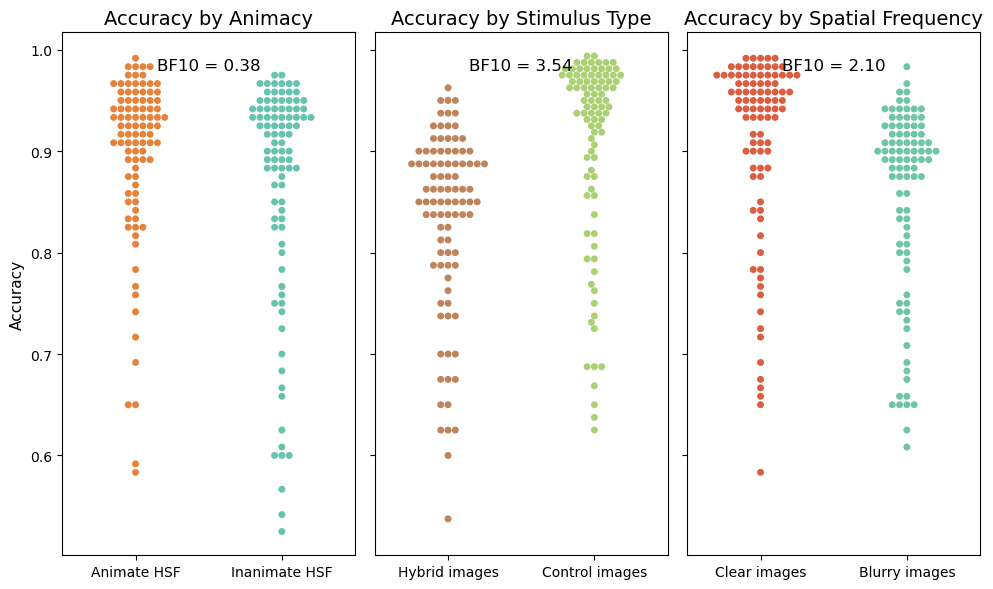

In [11]:
def add_bf_stars(ax, x1, x2, y, bf):
    if bf > 3:
        star = f'BF10 = {np.log10(bf):.2f}'
    elif bf > 10:
        star = f'BF10 = {np.log10(bf):.2f}'
    elif bf > 30:
        star = f'BF10 = {np.log10(bf):.2f}'
    else:
        star = f'BF10 = {np.log10(bf):.2f}'
    
    if star:
        ax.text(0.5, 0.95, star, ha='center', va='top', color='black', fontsize=12,
                transform=ax.transAxes)
    

colours1 = ['#C0845C', '#ABD173']
colours2 = ['#E5833A', '#65C3AF']
colours3 = ['#DD5D40', '#6FC5A7']

fontsize = 12
title_fontsize = 14
label_fontsize = 11
tick_fontsize = 10

fig, axes = plt.subplots(1, 3, figsize=(10, 6), sharey=True)

axes[0] = plt.subplot(1, 3, 1)
sns.swarmplot(data=Avg_acc[['animate', 'inanimate']], palette=colours2, ax=axes[0])
bf = bf_results['acc_animacy'].values[0]
y, h, col = Avg_acc[['animate', 'inanimate']].max().max() + 0.05, 0.02, 'k'
add_bf_stars(axes[0], 0, 1, y, bf)
axes[0].set_title('Accuracy by Animacy', fontsize=title_fontsize)
#axes[0].set_xlabel('Animacy', fontsize=label_fontsize)
axes[0].set_ylabel('Accuracy', fontsize=label_fontsize)  
axes[0].tick_params(axis='both', labelsize=tick_fontsize)
axes[0].set_xticklabels(['Animate HSF', 'Inanimate HSF'], fontsize=tick_fontsize)


axes[1] = plt.subplot(1, 3, 2)
sns.swarmplot(data=Avg_acc[['hybrid', 'control']], palette=colours1, ax=axes[1])
bf = bf_results['acc_stim_type'].values[0]
y, h, col = Avg_acc[['hybrid', 'control']].max().max() + 0.05, 0.02, 'k'
add_bf_stars(axes[1], 0, 1, y, bf)
axes[1].set_title('Accuracy by Stimulus Type', fontsize=title_fontsize)
#axes[1].set_xlabel('Stimulus Type', fontsize=label_fontsize)
axes[1].set_ylabel('') 
axes[1].tick_params(axis='both', labelsize=tick_fontsize)
axes[1].set_xticklabels(['Hybrid images', 'Control images'], fontsize=tick_fontsize)


axes[2] = plt.subplot(1, 3, 3)
sns.swarmplot(data=Avg_acc[['hsf', 'lsf']], palette=colours3, ax=axes[2])
bf = bf_results['acc_sf'].values[0]
y, h, col = Avg_acc[['hsf', 'lsf']].max().max() + 0.05, 0.02, 'k'
add_bf_stars(axes[2], 0, 1, y, bf)
axes[2].set_title('Accuracy by Spatial Frequency', fontsize=title_fontsize)
#axes[2].set_xlabel('Spatial Frequency', fontsize=label_fontsize)
axes[2].set_ylabel('')
axes[2].tick_params(axis='both', labelsize=tick_fontsize)
axes[2].set_xticklabels(['Clear images', 'Blurry images'], fontsize=tick_fontsize)



plt.tight_layout()
plt.show()

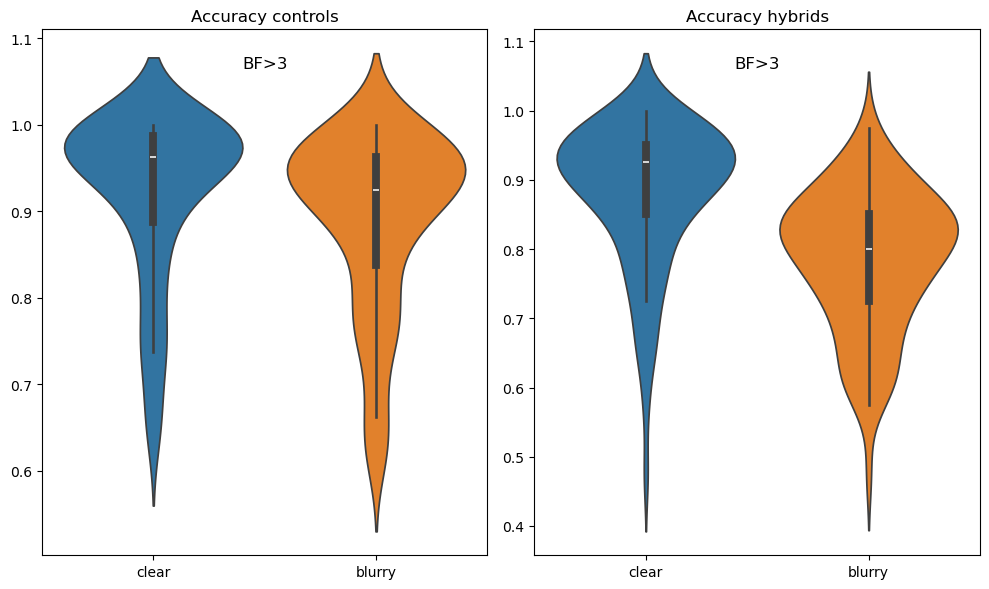

In [11]:
# adding bf stars when difference between conditions is significant




plt.figure(figsize=(10,6))
plt.subplot(1,2,1)
sns.violinplot(data=Avg_acc[['control_hsf','control_lsf']])
ax = plt.gca()
plt.xticks([0, 1], ['clear', 'blurry'])
plt.title('Accuracy controls')
bf = bf_results['acc_control_sf'].values[0]
y, h, col = Avg_acc[['control_hsf','control_lsf']].max().max() + 0.05, 0.01, 'k'
add_bf_stars(ax, 0, 1, y, bf)

plt.subplot(1,2,2)
sns.violinplot(data=Avg_acc[['hybrid_hsf','hybrid_lsf']])
ax = plt.gca()
plt.xticks([0, 1], ['clear', 'blurry'])
plt.title('Accuracy hybrids')
bf = bf_results['acc_hybrid_sf'].values[0]
y, h, col = Avg_acc[['hybrid_hsf','hybrid_lsf']].max().max() + 0.01, 0.01, 'k'
add_bf_stars(ax, 0, 1, y, bf)
plt.tight_layout()
plt.show()

### Accuracy per stimulus

In [9]:
code_list = ['stim000', 'stim001', 'stim002', 'stim003', 'stim004', 'stim005', 'stim006',
 'stim007', 'stim008', 'stim009', 'stim010', 'stim011', 'stim012', 'stim013',
 'stim014', 'stim015', 'stim016', 'stim017', 'stim018', 'stim019']


In [ ]:
#this doesn't work - unnecessary
# --- IGNORE ---

acc_perstim = pd.DataFrame()
subjectnr = np.unique(alldata['subject'])

for code in code_list:
    means_per_code = []
    for s in subjectnr:
        s_acc_perstim = []
        for i in range(len(alldata)):
            if alldata.iloc[i]['subject'] == s and code in alldata.iloc[i]['stim']:
                s_acc_perstim.append(alldata.iloc[i]['correct'])
        means_per_code.append(np.mean(s_acc_perstim))
    acc_perstim[code] = means_per_code

acc_perstim.index = subjectnr

In [12]:
blur_conditions = [0, 1]  # 0 clear, 1 blurred
blur_labels = ['clear', 'blurred']

acc_blur_stim = pd.DataFrame(index=blur_labels, columns=code_list)

for blur, label in zip(blur_conditions, blur_labels):
    for code in code_list:
        mask = (alldata['blurred'] == blur) & (alldata['stim'].str.contains(code))
        acc_blur_stim.loc[label, code] = alldata.loc[mask, 'correct'].mean()


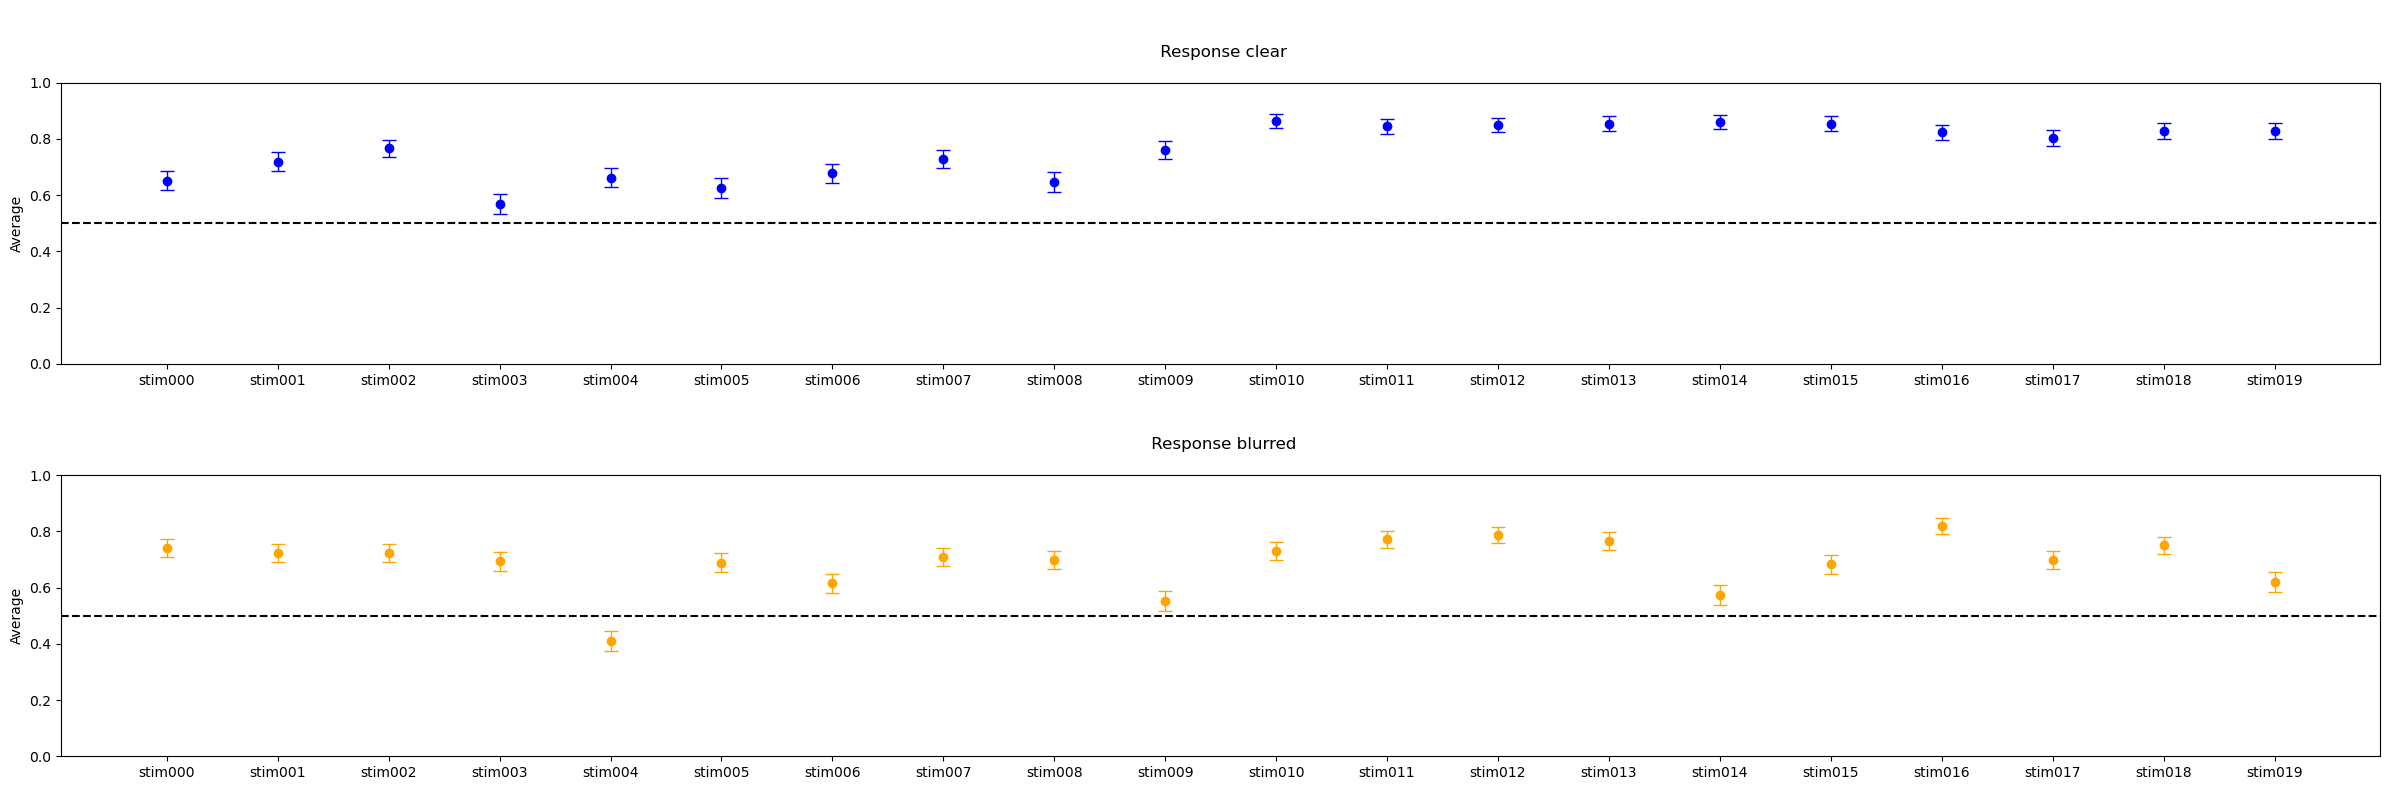

In [15]:
fig, axs = plt.subplots(2, 1, figsize=(24, 8), sharex=False)

for i, blur_label in enumerate(['clear', 'blurred']):
    means = []
    sems = []
    for stim in code_list:
        mask = (alldata['blurred'] == i) & (alldata['stim'].str.contains(stim))
        data = alldata.loc[mask, 'correct']
        means.append(data.mean())
        sems.append(stats.sem(data) if len(data) > 1 else 0)
    axs[i].errorbar(code_list, means, yerr=sems, fmt='o', color='blue' if i == 0 else 'orange', elinewidth=1, capsize=5)
    axs[i].set_title(f'\n\n Response {blur_label}\n')
    axs[i].set_ylabel('Average')
    axs[i].set_ylim(0, 1)
    axs[i].axhline(0.5, color='black', linestyle='--')


plt.xticks()
plt.tight_layout()
plt.show()

### Categorisation

In [12]:
catdata = pd.DataFrame() 

s = 0

anim = []
for f in datapath:
    df = pd.read_csv(f)
    if len(df) == 1452:
        if s+1 not in outliers:
            s+=1
            clean_data = df.dropna(subset=['stim'])
            clean_data = clean_data[clean_data['test_part']=='response']
            clean_data['subject'] = s
            clean_data['inanimate'] = [int('inanimate' in x) for x in clean_data['stim']] #0 animate, 1 inanimate
            clean_data['control'] = [int('stim1' in x) for x in clean_data['stim']] #0 hybrids, 1 controls
            clean_data['blurred'] = [int('blurred' in x) for x in clean_data['stim']] # 0 normal, 1 blurred

            for idx, row in clean_data.iterrows():
                response = row['response']
                task = row['task']

                if '[z] inanimate' in task and response == 'z':
                    anim.append('inanimate')
                elif '[z] inanimate' in task and response == 'm':
                    anim.append('animate')
                elif '[z] animate' in task and response == 'z':
                    anim.append('animate')
                elif '[z] animate' in task and response == 'm':
                    anim.append('inanimate')

            catdata = pd.concat((catdata,clean_data))
        else:
            s+=1
            print('excluded subject', s)

catdata['anim'] = anim

excluded subject 3
excluded subject 5
excluded subject 6
excluded subject 10
excluded subject 11
excluded subject 12
excluded subject 16
excluded subject 18
excluded subject 21
excluded subject 22
excluded subject 27
excluded subject 29
excluded subject 38
excluded subject 39
excluded subject 40
excluded subject 44
excluded subject 45
excluded subject 49
excluded subject 50
excluded subject 60
excluded subject 61
excluded subject 63
excluded subject 64
excluded subject 65
excluded subject 67
excluded subject 80
excluded subject 81
excluded subject 83
excluded subject 84
excluded subject 89
excluded subject 90
excluded subject 94
excluded subject 101
excluded subject 107
excluded subject 110
excluded subject 117
excluded subject 120
excluded subject 123
excluded subject 124
excluded subject 127
excluded subject 130


In [13]:
code_list = {'stim000':'flowers-dogs', 'stim001':'armchairs-butterflies', 'stim002':'armchairs-chickens',
            'stim003':'fruits-beetles', 'stim004':'fruits-lizards', 'stim005':'fruits-butterflies',
            'stim006':'fruits-parrots', 'stim007': 'bottles-chickens', 'stim008':'pillows-beetles',
            'stim009': 'handbags-lizards', 'stim010': 'stim010-animate-parrots-fruits', 
            'stim011':'stim011-animate-parrots-fruits', 'stim012': 'chickens-pillows', 
            'stim013':'chickens-armchairs', 'stim014': 'birds-bottles', 
            'stim015': 'birds-fruits', 'stim016': 'fish-pillows', 
            'stim017': 'butterflies-handbags', 'stim018':'beetles-fruits', 'stim019': 'peacocks-flowers'} #only hybrids

In [14]:
means_clear = []
means_blurry = []
sems_clear = []
sems_blurry = []

value_list = []
for stim, value in code_list.items():
    value_list.append(value)
    mask_clear = (catdata['blurred'] == 0) & (catdata['stim'].str.contains(stim)) #clear+hybrids
    mask_blurry = (catdata['blurred'] == 1) & (catdata['stim'].str.contains(stim)) #blurry+hybrids
    data_clear = catdata.loc[mask_clear, 'anim'].apply(lambda x: 1 if x == 'animate' else 0) #double-check this
    data_blurry = catdata.loc[mask_blurry, 'anim'].apply(lambda x: 1 if x == 'animate' else 0)
    means_clear.append(data_clear.mean())
    means_blurry.append(data_blurry.mean())
    sems_clear.append(stats.sem(data_clear) if len(data_clear) > 1 else 0)
    sems_blurry.append(stats.sem(data_blurry) if len(data_blurry) > 1 else 0)


catdata = pd.DataFrame({
    'stimulus': value_list,
    'mean_clear': means_clear,
    'mean_blurry': means_blurry,
    'sem_clear': sems_clear,
    'sem_blurry': sems_blurry
})


with open('categorisation_stim.csv','w') as out:
    catdata.to_csv(out,index_label='index')

In [15]:
catdata_sorted = pd.read_csv('catdata_sorted.csv')
code_list_sorted = catdata_sorted['stimulus']
means_clear_sorted = catdata_sorted['mean_clear']
sems_clear_sorted = catdata_sorted['sem_clear']

means_blurry_sorted = catdata_sorted['mean_blurry']
sems_blurry_sorted = catdata_sorted['sem_blurry']

Clear: 0.946236559139785, Blurry: 0.2365591397849462, Abs Diff: 0.7096774193548387
Clear: 0.946236559139785, Blurry: 0.2258064516129032, Abs Diff: 0.7204301075268817
Clear: 0.9301075268817204, Blurry: 0.0913978494623656, Abs Diff: 0.8387096774193548
Clear: 0.9247311827956988, Blurry: 0.2096774193548387, Abs Diff: 0.71505376344086
Clear: 0.9247311827956988, Blurry: 0.4139784946236559, Abs Diff: 0.5107526881720429
Clear: 0.9193548387096774, Blurry: 0.1236559139784946, Abs Diff: 0.7956989247311828
Clear: 0.9193548387096774, Blurry: 0.3387096774193548, Abs Diff: 0.5806451612903225
Clear: 0.913978494623656, Blurry: 0.1129032258064516, Abs Diff: 0.8010752688172044
Clear: 0.9086021505376344, Blurry: 0.1344086021505376, Abs Diff: 0.7741935483870968
Clear: 0.9032258064516128, Blurry: 0.2043010752688172, Abs Diff: 0.6989247311827955
Clear: 0.3709677419354839, Blurry: 0.8440860215053764, Abs Diff: 0.4731182795698925
Clear: 0.2365591397849462, Blurry: 0.8064516129032258, Abs Diff: 0.56989247311827

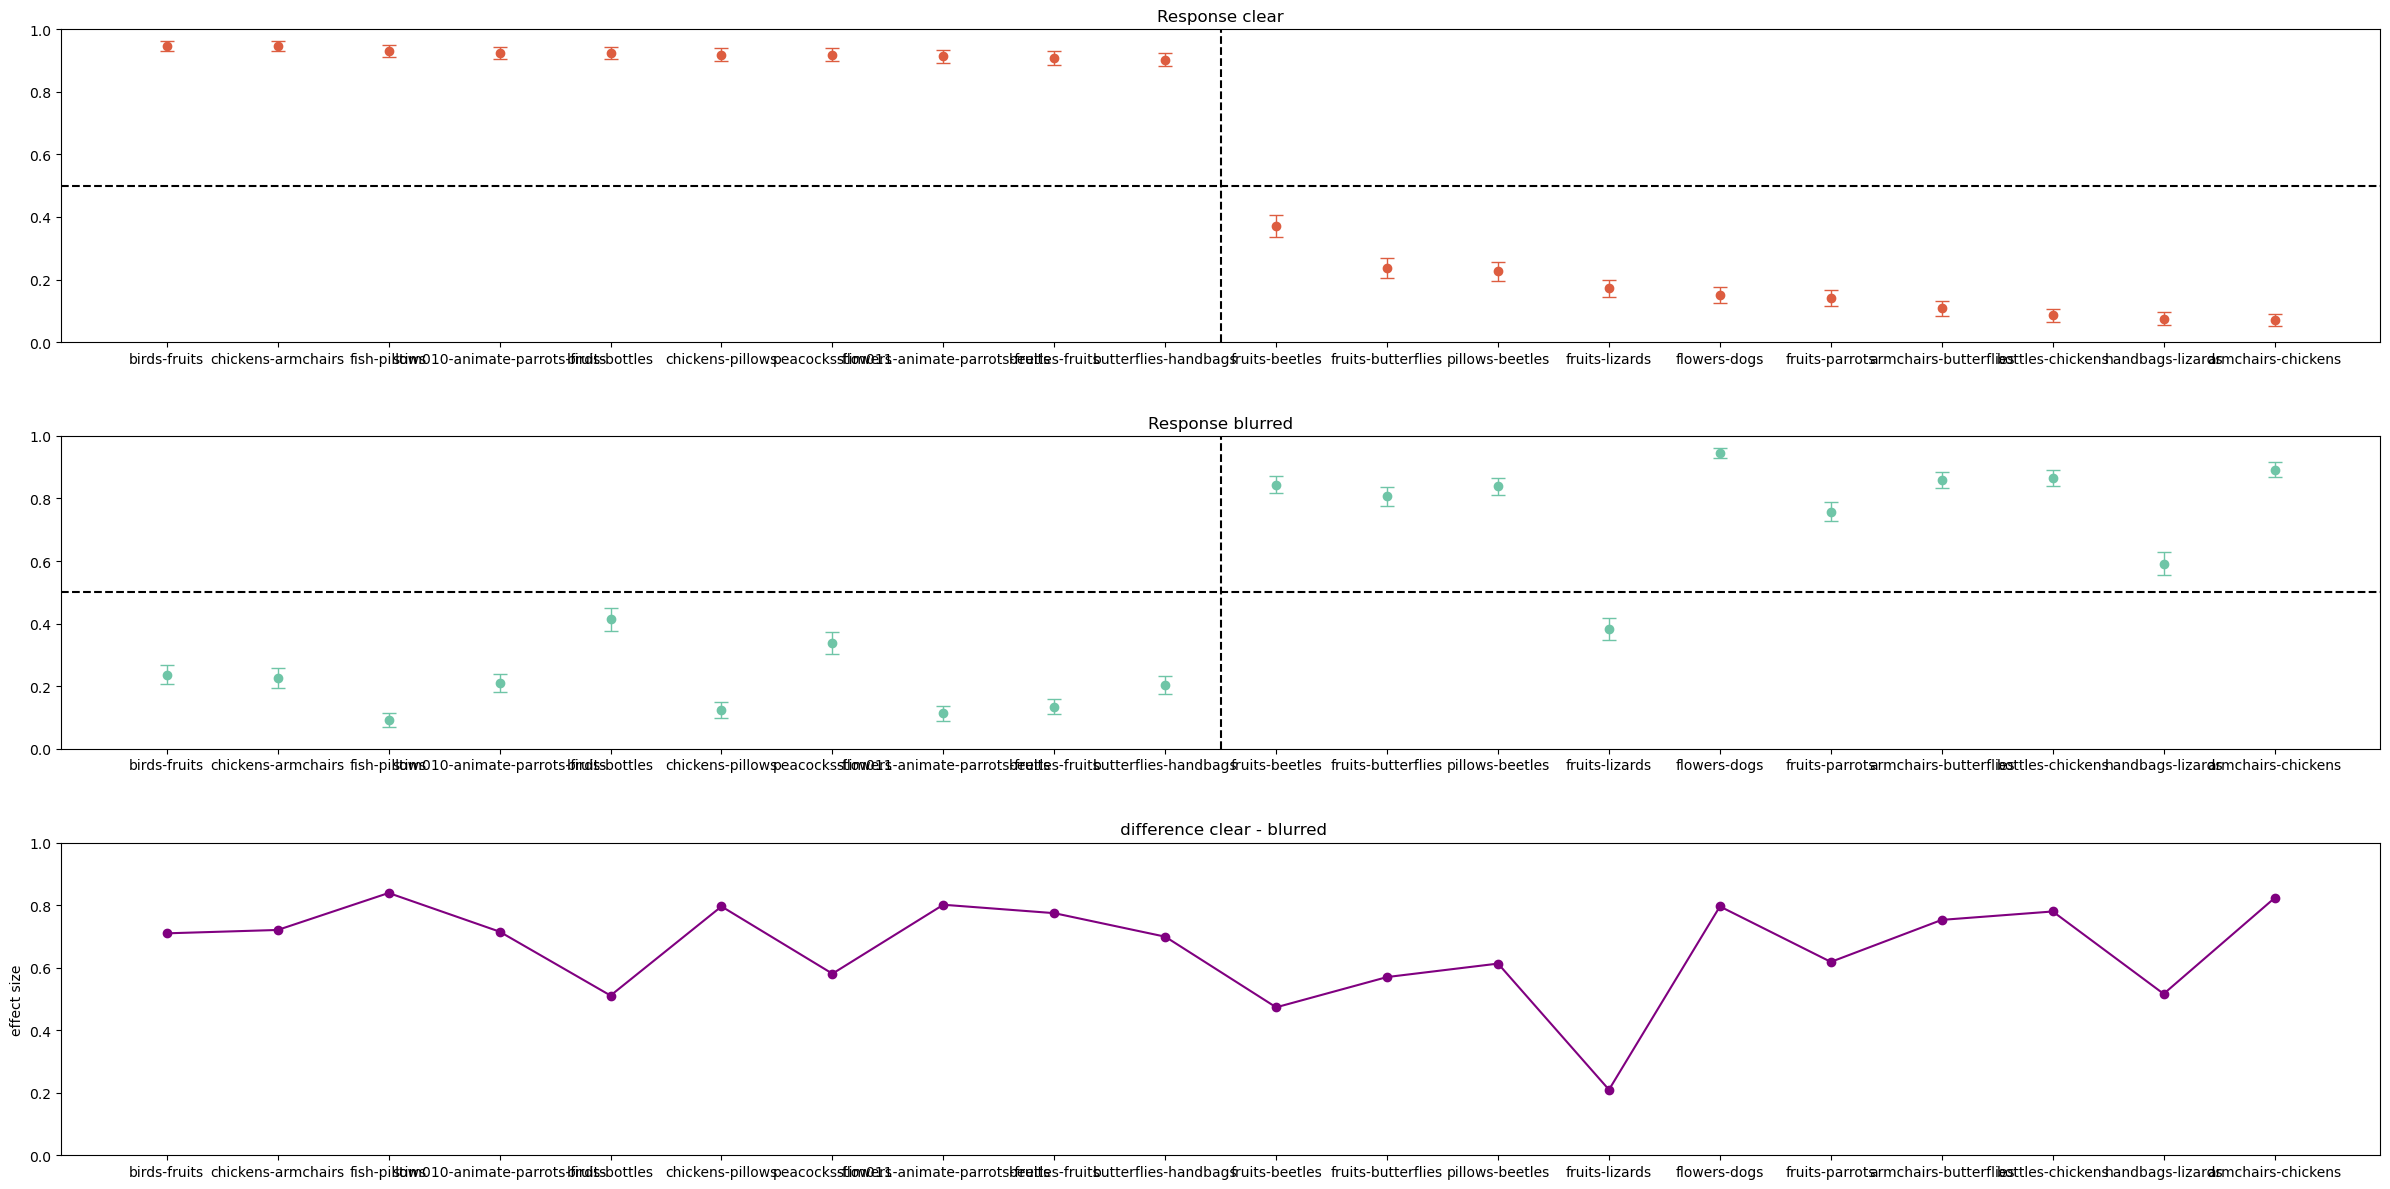

In [17]:
fig, axs = plt.subplots(3, 1, figsize=(24, 12))

colours3 = ['#DD5D40', '#6FC5A7']

#clear
axs[0].errorbar(code_list_sorted, means_clear_sorted, yerr=sems_clear_sorted, fmt='o', color='#DD5D40', elinewidth=1, capsize=5)
axs[0].set_title('Response clear')
axs[0].set_ylabel(' ')
axs[0].set_ylim(0, 1)
axs[0].axhline(0.5, color='black', linestyle='--')
axs[0].axvline(9.5, color='black', linestyle='--')

#blurry
axs[1].errorbar(code_list_sorted, means_blurry_sorted, yerr=sems_blurry_sorted, fmt='o', color='#6FC5A7', elinewidth=1, capsize=5)
axs[1].set_title('\n\nResponse blurred')
axs[1].set_ylabel(' ')
axs[1].set_ylim(0, 1)
axs[1].axhline(0.5, color='black', linestyle='--')
axs[1].axvline(9.5, color='black', linestyle='--')

#diff
abs_diff = []
for c, b in zip(means_clear_sorted, means_blurry_sorted):
    print(f'Clear: {c}, Blurry: {b}, Abs Diff: {abs(c - b)}') #DEBUG
    diff = abs(c - b)
    abs_diff.append(diff)

axs[2].plot(code_list_sorted, abs_diff, marker='o', color='purple')
axs[2].set_title('\n\n difference clear - blurred')
axs[2].set_ylabel('effect size')
axs[2].set_ylim(0, 1)


plt.tight_layout()
plt.show()

# Reaction time

+ uses median instead of mean
+ only taking RTs of correct responses
+ trimming participants with 2.5SD above median RT
        (not done yet:)
       


### RT accross different conditions

In [34]:
subjectnr = np.unique(alldata['subject'])

alldata['inanimate'] = alldata['inanimate'].astype(int)
alldata['control'] = alldata['control'].astype(int)
alldata['blurred'] = alldata['blurred'].astype(int)

rt_animacy = alldata.loc[alldata['correct'] == 1].groupby(['subject', 'inanimate'])['rt'] \
                    .median().unstack(fill_value=np.nan) \
                    .rename(columns={0: 'animate', 1: 'inanimate'})

rt_type = alldata.loc[alldata['correct'] == 1].groupby(['subject', 'control'])['rt'] \
                    .median().unstack(fill_value=np.nan) \
                    .rename(columns={0: 'hybrid', 1: 'control'})

rt_blur = alldata.loc[alldata['correct'] == 1].groupby(['subject', 'blurred'])['rt'] \
                    .median().unstack(fill_value=np.nan) \
                    .rename(columns={0: 'hsf', 1: 'lsf'})

rt_comb = alldata.loc[alldata['correct'] == 1].groupby(['subject', 'control', 'blurred'])['rt'] \
                .median().unstack(level=[1, 2])

# mapping tuples -> new names
mapping_rt = {
    (1, 0): 'control_hsf',
    (1, 1): 'control_lsf',
    (0, 0): 'hybrid_hsf',
    (0, 1): 'hybrid_lsf'
}

# assign new single-level column names
rt_comb.columns = [mapping_rt.get(tuple(col), tuple(col)) for col in rt_comb.columns]

# combine into one per-subject DataFrame
Avg_rt = pd.concat([rt_animacy, rt_type, rt_blur, rt_comb], axis=1)

# reorder columns if present
cols_rt = ['animate','inanimate','hybrid','control','hsf','lsf',
        'control_lsf','control_hsf','hybrid_hsf','hybrid_lsf']
Avg_rt = Avg_rt.reindex(columns=[c for c in cols_rt if c in Avg_rt.columns])
Avg_rt.to_csv('average_rt.csv', index_label='subject')


#### Cleaning data

In [56]:
#COPILOT GENERATED

median_rts = Avg_rt.median()
std_rts = Avg_rt.std()

# outlier range
upper_bound = median_rts + 2.5 * std_rts
#lower_bound = median_rts - 2.5 * std_rts
print('lower bound', upper_bound)

# build per-column boolean dataframe marking subjects below the lower bound
outliers = pd.DataFrame(index=Avg_rt.index)

for col, value in Avg_rt.items():
    outliers[f'outlier_{col}'] = value > upper_bound[col]
    #outliers[f'outlier_{col}'] = value < lower_bound[col]

# determine subjects that are outliers in any column
outlier_subjects = outliers.any(axis=1)

# log which subjects will be removed and why
out_rt = []
for subj, is_out in outlier_subjects.items():
    if is_out:
        triggered = outliers.columns[outliers.loc[subj]].tolist()
        out_rt.append(int(subj))
        print(f'Removing subjectnr {subj} because of {triggered}')

# drop only the flagged subjects
Avg_rt_clean = Avg_rt.drop(index=outlier_subjects[outlier_subjects].index)
Avg_rt_clean.to_csv('average_rt_cleaned.csv', index_label='subject')

print(out_rt)

lower bound animate          698.254219
inanimate        776.959892
hybrid           753.995877
control          758.748635
hsf              790.709394
lsf              729.144117
control_lsf      781.503515
control_hsf    90567.421692
hybrid_hsf       751.388094
hybrid_lsf       784.325050
dtype: float64
Removing subjectnr 55 because of ['outlier_animate', 'outlier_hybrid', 'outlier_hybrid_hsf']
Removing subjectnr 80 because of ['outlier_control_lsf']
Removing subjectnr 106 because of ['outlier_hybrid_lsf']
Removing subjectnr 123 because of ['outlier_animate', 'outlier_inanimate', 'outlier_hybrid', 'outlier_control', 'outlier_hsf', 'outlier_control_hsf', 'outlier_hybrid_hsf']
[55, 80, 106, 123]


#### Plots

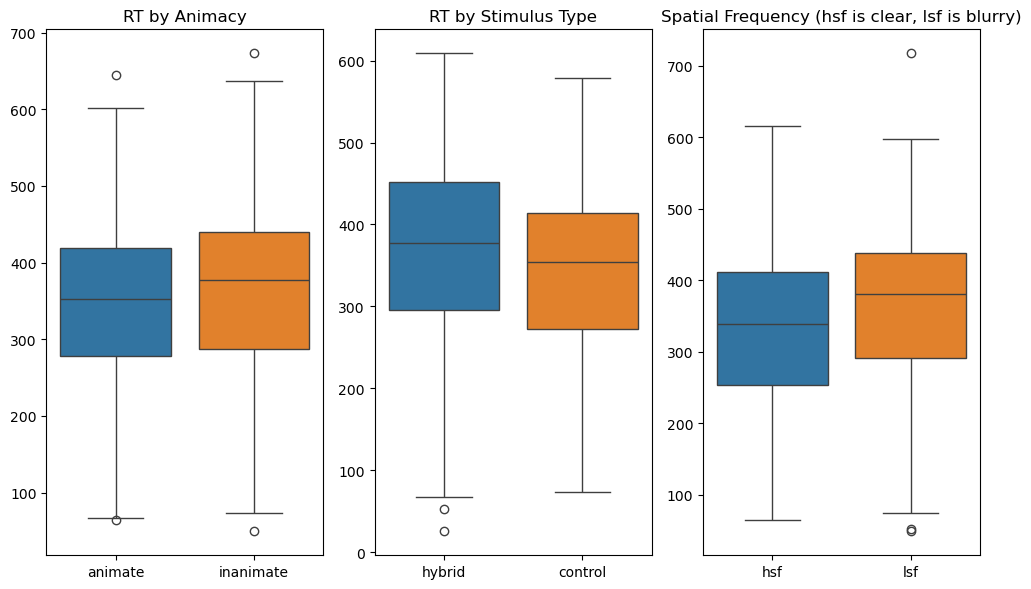

In [83]:
#plotting rt
plt.figure(figsize=(10,6))
plt.subplot(1,3,1)
sns.boxplot(data=Avg_rt_clean[['animate','inanimate']])
plt.title('RT by Animacy')
plt.subplot(1,3,2)
sns.boxplot(data=Avg_rt_clean[['hybrid','control']])
plt.title('RT by Stimulus Type')
plt.subplot(1,3,3)
sns.boxplot(data=Avg_rt_clean[['hsf','lsf']])
plt.title('Spatial Frequency (hsf is clear, lsf is blurry)')
plt.tight_layout()
plt.show()

### RT per stimulus

In [61]:
code_list = ['stim000', 'stim001', 'stim002', 'stim003', 'stim004', 'stim005', 'stim006',
 'stim007', 'stim008', 'stim009', 'stim010', 'stim011', 'stim012', 'stim013',
 'stim014', 'stim015', 'stim016', 'stim017', 'stim018', 'stim019'] #only hybrids

In [75]:
print(out_rt)

[55, 80, 106, 123]


In [78]:
catdata_rt = pd.DataFrame() 

s = 0

anim = []
for f in datapath:
    df = pd.read_csv(f)
    if len(df) == 1452:
        if s+1 not in out_rt:
            s+=1
            clean_data = df.dropna(subset=['stim'])
            clean_data = alldata[(alldata['test_part'] == 'response') & (alldata['correct'] == 1)].copy()
            clean_data['subject'] = s
            clean_data['inanimate'] = [int('inanimate' in x) for x in clean_data['stim']] #0 animate, 1 inanimate
            clean_data['blurred'] = [int('blurred' in x) for x in clean_data['stim']] # 0 normal, 1 blurred
            catdata_rt = pd.concat((catdata_rt, clean_data), ignore_index=True)
        else:
            s+=1
            print(f'Skipping subject {s}')


means_clear = []
means_blurry = []
sems_clear = []
sems_blurry = []

for stim in code_list:
    mask_clear = (catdata_rt['blurred'] == 0) & (catdata_rt['stim'].str.contains(stim))
    mask_blur  = (catdata_rt['blurred'] == 1) & (catdata_rt['stim'].str.contains(stim))
    data_clear = catdata_rt.loc[mask_clear, 'rt']
    data_blur  = catdata_rt.loc[mask_blur, 'rt']
    means_clear.append(data_clear.median() if len(data_clear)>0 else np.nan)
    means_blurry.append(data_blur.median() if len(data_blur)>0 else np.nan)
    sems_clear.append(stats.sem(data_clear) if len(data_clear)>1 else 0)
    sems_blurry.append(stats.sem(data_blur) if len(data_blur)>1 else 0)


Skipping subject 55 due to outlier status.
Skipping subject 80 due to outlier status.
Skipping subject 106 due to outlier status.
Skipping subject 123 due to outlier status.


Clear: 395.0, Blurry: 361.5, Abs Diff: 33.5
Clear: 379.0, Blurry: 419.0, Abs Diff: 40.0
Clear: 400.0, Blurry: 368.0, Abs Diff: 32.0
Clear: 450.0, Blurry: 395.5, Abs Diff: 54.5
Clear: 408.5, Blurry: 428.0, Abs Diff: 19.5
Clear: 451.0, Blurry: 417.0, Abs Diff: 34.0
Clear: 405.5, Blurry: 408.0, Abs Diff: 2.5
Clear: 398.0, Blurry: 368.5, Abs Diff: 29.5
Clear: 425.0, Blurry: 397.5, Abs Diff: 27.5
Clear: 377.0, Blurry: 454.5, Abs Diff: 77.5
Clear: 359.5, Blurry: 429.0, Abs Diff: 69.5
Clear: 366.0, Blurry: 417.0, Abs Diff: 51.0
Clear: 399.5, Blurry: 427.5, Abs Diff: 28.0
Clear: 333.0, Blurry: 485.0, Abs Diff: 152.0
Clear: 383.5, Blurry: 387.0, Abs Diff: 3.5
Clear: 336.0, Blurry: 404.5, Abs Diff: 68.5
Clear: 331.0, Blurry: 370.0, Abs Diff: 39.0
Clear: 368.0, Blurry: 434.0, Abs Diff: 66.0
Clear: 382.0, Blurry: 379.0, Abs Diff: 3.0
Clear: 387.0, Blurry: 437.0, Abs Diff: 50.0


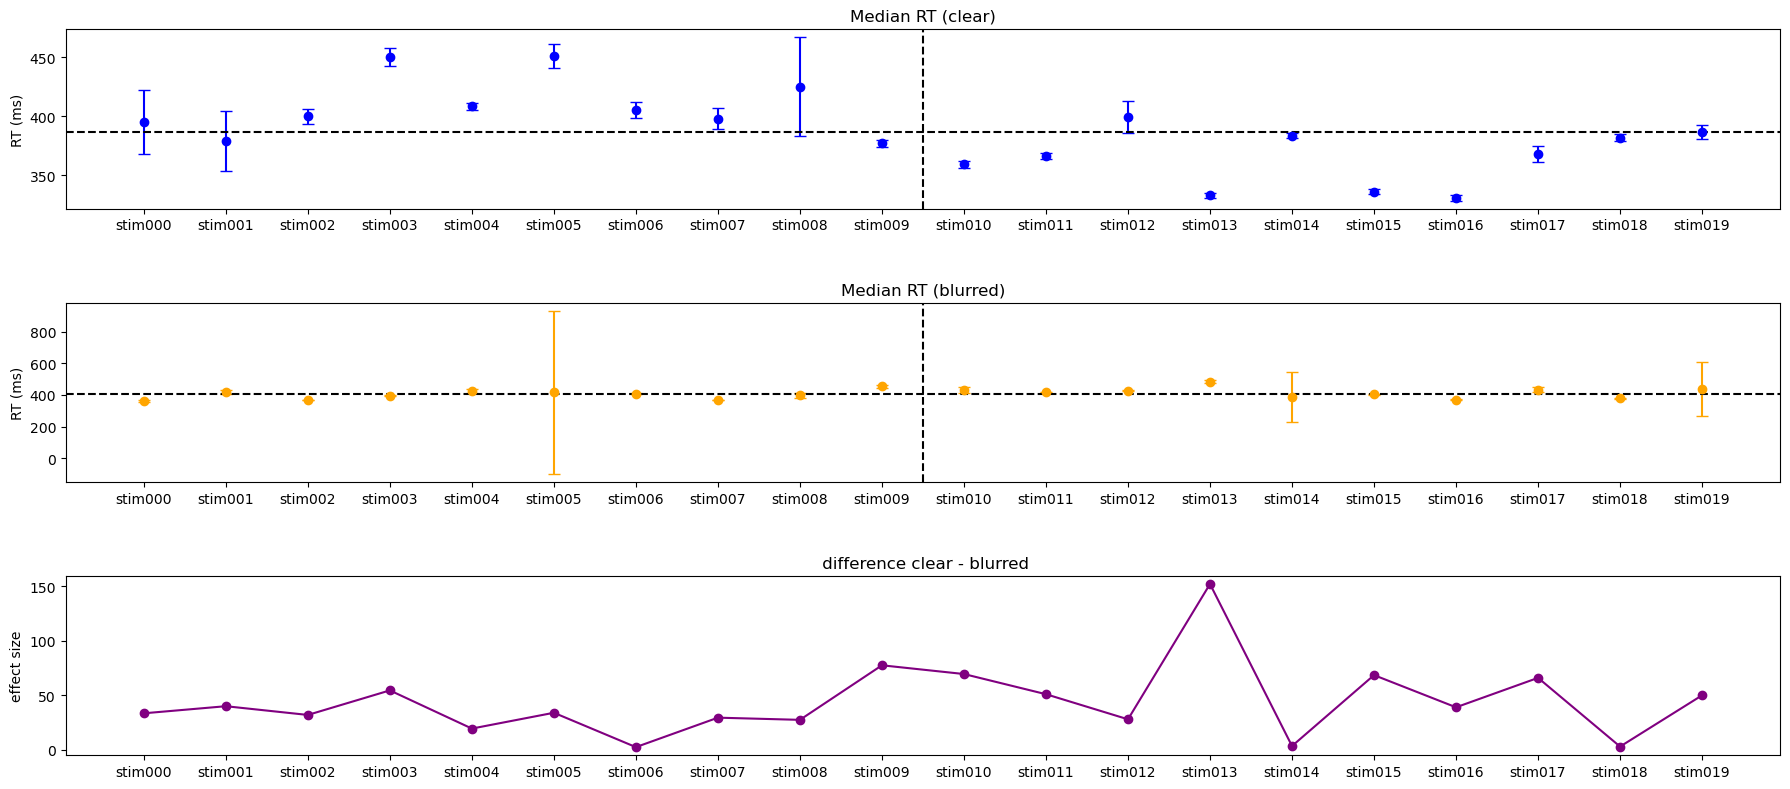

In [80]:
fig, axs = plt.subplots(3, 1, figsize=(18,8))
axs[0].errorbar(code_list, means_clear, yerr=sems_clear, fmt='o', color='blue', capsize=4)
axs[0].set_title('Median RT (clear)')
axs[0].set_ylabel('RT (ms)')
axs[0].axhline(np.mean(np.array(means_clear)), color='black', linestyle='--')
axs[0].axvline(9.5, color='black', linestyle='--')

axs[1].errorbar(code_list, means_blurry, yerr=sems_blurry, fmt='o', color='orange', capsize=4)
axs[1].set_title('Median RT (blurred)')
axs[1].set_ylabel('RT (ms)')
axs[1].axhline(np.mean(np.array(means_blurry)), color='black', linestyle='--')
axs[1].axvline(9.5, color='black', linestyle='--')

#diff
abs_diff = []
for c, b in zip(means_clear, means_blurry):
    print(f'Clear: {c}, Blurry: {b}, Abs Diff: {abs(c - b)}') #DEBUG
    diff = abs(c - b)
    abs_diff.append(diff)

axs[2].plot(code_list, abs_diff, marker='o', color='purple')
axs[2].set_title('\n\n difference clear - blurred')
axs[2].set_ylabel('effect size')


plt.tight_layout()
plt.show()

# Wrong or old

Crashes-> more efficient code rn

In [ ]:
# WRONG -> UNNECESSARY LOOPS -> CRASHES

subjectnr = np.unique(alldata['subject'])

acc_animate = []
acc_inanimate = []
acc_hybrid = []
acc_control = []
acc_lsf = []
acc_hsf = []
acc_control_lsf = []
acc_control_hsf = []
acc_hybrid_hsf = []
acc_hybrid_lsf = []
for s in subjectnr:
    s_acc_animate = []
    s_acc_inanimate = []
    s_acc_hybrid = []
    s_acc_control = []
    s_acc_lsf = []
    s_acc_hsf = []
    s_acc_control_lsf = []
    s_acc_control_hsf = []
    s_acc_hybrid_hsf = []
    s_acc_hybrid_lsf = []

    for i in range(len(alldata)):
        print(f'subject: {s}, row: {i}')
        if alldata.iloc[i]['subject'] == s:
            if alldata.iloc[i]['inanimate'] == 0:
                s_acc_animate.append(alldata.iloc[i]['correct'])
            else:
                s_acc_inanimate.append(alldata.iloc[i]['correct'])
    
            if alldata.iloc[i]['control'] == 0:
                s_acc_hybrid.append(alldata.iloc[i]['correct'])
            else:
                s_acc_control.append(alldata.iloc[i]['correct'])
    
            if alldata.iloc[i]['blurred'] == 0:
                s_acc_hsf.append(alldata.iloc[i]['correct'])
            else:
                s_acc_lsf.append(alldata.iloc[i]['correct'])

            if alldata.iloc[i]['blurred'] == 1 and alldata.iloc[i]['control'] == 1:
                s_acc_control_lsf.append(alldata.iloc[i]['correct'])
            elif alldata.iloc[i]['blurred'] == 0 and alldata.iloc[i]['control'] == 1:
                s_acc_control_hsf.append(alldata.iloc[i]['correct'])
    
            if alldata.iloc[i]['blurred'] == 1 and alldata.iloc[i]['control'] == 0:
                s_acc_hybrid_lsf.append(alldata.iloc[i]['correct'])
            elif alldata.iloc[i]['blurred'] == 0 and alldata.iloc[i]['control'] == 0:
                s_acc_hybrid_hsf.append(alldata.iloc[i]['correct'])

    acc_animate.append(s_acc_animate)
    acc_inanimate.append(s_acc_inanimate)
    acc_hybrid.append(s_acc_hybrid)
    acc_control.append(s_acc_control)
    acc_lsf.append(s_acc_lsf)
    acc_hsf.append(s_acc_hsf)
    acc_control_lsf.append(s_acc_control_lsf)
    acc_control_hsf.append(s_acc_control_hsf)
    acc_hybrid_hsf.append(s_acc_hybrid_hsf)
    acc_hybrid_lsf.append(s_acc_hybrid_lsf)



In [ ]:
#unnecesary??
Avg_acc = pd.DataFrame()
Avg_acc['animate'] = np.mean(np.array(acc_animate),axis=1)
Avg_acc['inanimate'] = np.mean(np.array(acc_inanimate),axis=1)
Avg_acc['hybrid'] = np.mean(np.array(acc_hybrid),axis=1)
Avg_acc['control'] = np.mean(np.array(acc_control),axis=1)
Avg_acc['lsf'] = np.mean(np.array(acc_lsf),axis=1)
Avg_acc['hsf'] = np.mean(np.array(acc_hsf),axis=1)
Avg_acc['control_lsf'] = np.mean(np.array(acc_control_lsf),axis=1)
Avg_acc['control_hsf'] = np.mean(np.array(acc_control_hsf),axis=1)
Avg_acc['hybrid_hsf'] = np.mean(np.array(acc_hybrid_hsf),axis=1)
Avg_acc['hybrid_lsf'] = np.mean(np.array(acc_hybrid_lsf),axis=1)

with open('average_accuracy.csv','w') as out:
    Avg_acc.to_csv(out,index_label='index')

Plot just to see the control outliers

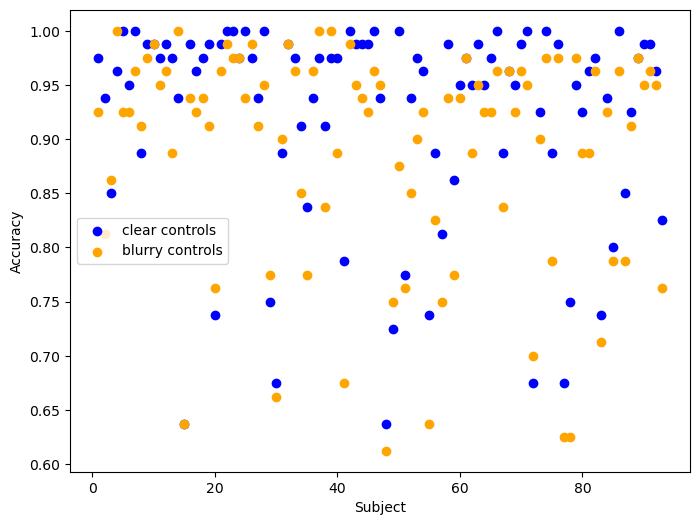

93


In [25]:
#control accuracy (y-axis) per subject (x-axis) ((for trimming purposes if needed))
plt.figure(figsize=(8,6))
plt.scatter(x=range(1,len(Avg_acc)+1), y=Avg_acc['control_hsf'], label='clear controls', color='blue')
plt.scatter(x=range(1,len(Avg_acc)+1), y=Avg_acc['control_lsf'], label='blurry controls', color='orange')
plt.xlabel('Subject')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

print(len(Avg_acc))
